### Exploration and data loading


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
##checking for running in the correct venv
import sys
sys.executable

'c:\\Users\\o1Lar\\Documents\\2025\\Python stuff\\ML_PROJECT\\.venv\\Scripts\\python.exe'

In [3]:
df = pd.read_csv(r"C:\Users\o1Lar\Documents\2025\Python stuff\ML_PROJECT\data\raw\Telco-Customer-Churn.csv")
df.shape

(7043, 21)

In [4]:
df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [5]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


- For features with 3 or more categorical variables, we do One-Hot Encoding
- For binary features we do 0 and 1 .

### Binary Encoding

In [6]:
# binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

# replacing Yes/No with 0 and 1
df[binary_cols] = df[binary_cols].replace({
    'Yes': 1, 'No': 0,
    'Male': 1, 'Female': 0
})


C:\Users\o1Lar\AppData\Local\Temp\ipykernel_3172\1584716773.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({


In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


### One-Hot Encoding

In [8]:
# Categorical variables with with > 2 unique values:
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

# One-Hot Encoding

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,False,False,False,False,False,False,False,False,True,False


### Cleaning

In [10]:
df = df.drop('customerID', axis=1)
# irrelevant 

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# was unicode, but now numeric

In [12]:
# converting newly One-Hot encoded booleans into binary (1 / 0)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int) 


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

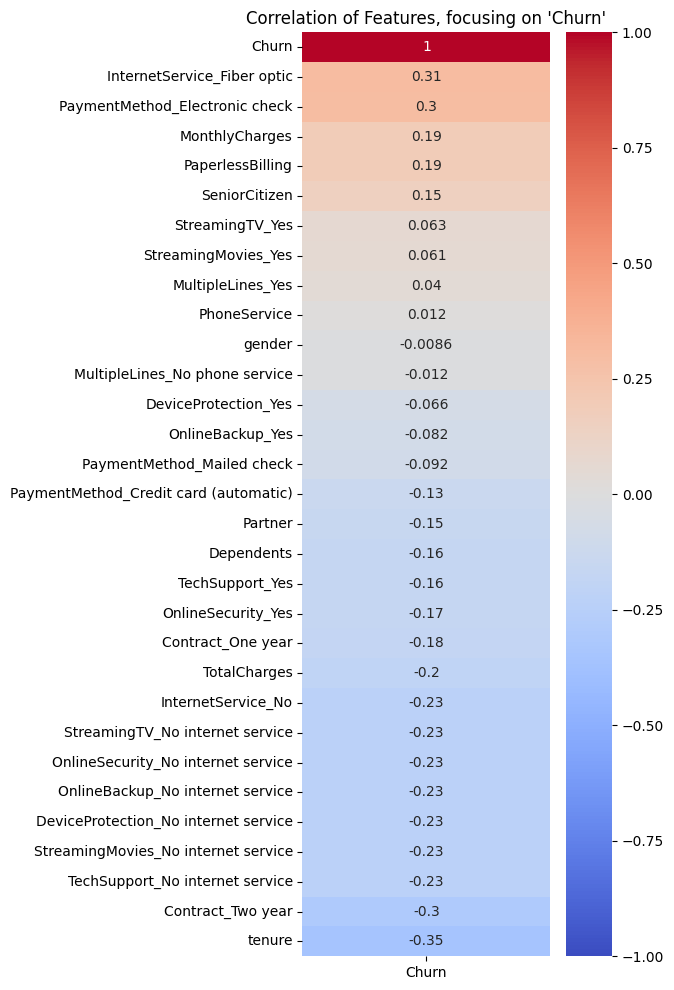

In [14]:
# Computing correlation matrix for only numeric columns:
corr_matrix = df.corr(numeric_only=True)

# Checking correlation, focusing on 'Churn'
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

# plotting heatmap
plt.figure(figsize=(4, 12))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation of Features, focusing on 'Churn'")
plt.show()

Positive features: (Higher value -> more likely to churn)
-- InternetService_Fiber optic (+0.31) -> Customers who has optic are more likely to churn
-- PaymentMethod_Electronic check (+0.30) -> Users who pays with check are more likely to churn

Negative features: (Lower value -> less likely to churn)
-- tenure (-0.35) -> Customers who stay longer are less likely to churn
-- Contract_Two year (-0.35) -> Customers who has a two year contract are less likely to churn 


 

### Checking for multicolinearity (VIF)

We check for multicolinearity using VIF (Variance Inflation Factors),
which gives us a value of how much a predictor is correlated to other predictors
- VIF = 1 indicates no multicolinearity
- VIF = 1-5 is moderate
- VIF > 5 is high multicolinearity

In [15]:
## Collapsing redundant columns before running VIF
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)

## Dropping original redundant dummies
drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns=drop_cols)

## Handling PhoneService redundancy
if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])



In [16]:
## Preparing X
X = df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [17]:
## Running VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# removing rows with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)



c:\Users\o1Lar\Documents\2025\Python stuff\ML_PROJECT\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  feature          VIF
11                     InternetService_No          inf
23                    No_internet_service          inf
5                            PhoneService  1773.528816
7                          MonthlyCharges   866.089640
10            InternetService_Fiber optic   148.500814
24                       No_phone_service    60.842267
17                    StreamingMovies_Yes    24.156394
16                        StreamingTV_Yes    24.080019
8                            TotalCharges    10.811490
4                                  tenure     7.584453
9                       MultipleLines_Yes     7.289761
14                   DeviceProtection_Yes     6.924754
13                       OnlineBackup_Yes     6.796678
15                        TechSupport_Yes     6.476508
12                     OnlineSecurity_Yes     6.338349
19                      Contract_Two year     2.652328
21         PaymentMethod_Electronic check     1.976032
22        

Looking at this we can clearly see that there is multicolinearity between features
- To handle this, there are several approaches: we can drop features or use other techniques such as Lasso or Ridge regression
- OR we can choose a tree based model, because these handles multicolinearity better than other models, as they aren't that sensitive
- Here redundant features just "compete" with eachother, instead of causing unstable predictions

### Machine Learning

In [18]:
### we have a class imbalance
df['Churn'].value_counts()

## in percentage
df['Churn'].value_counts(normalize=True) * 100

## Given the imbalance of ~27% churners, we do class weighing and threshold tuning, which should be enough


Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64



In churn prediction, recall (and F1) is usually the most important - this is because:

- Business context Churn prediction is asymmetric in cost, because missing potential churners usually costs more than wrongly targeting a loyal customer.
- We therefore want to focus on minimizing the "False Negatives" (FN) as much as possible, which means that we want to focus on improving recall
- However this ALSO means we would be loosing precision by doing this, however this is a tradeoff that can be discussed depending on the business problem

This is how we would prioritize depending on the business:

- If retention campaigns are cheap --> prioritize recall (catch every possible churner).
- If retention campaigns are expensive --> balance precision and recall using F1 score or a precision-recall trade-off.
- Another strategy if retention is expensive is creating a ranking of churn risk --> if so, we use ROC-AUC or PR-AUC to evaluate the model.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

## preparing data
X = df.drop(columns=['Churn'])
y = df['Churn']

## creating the train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

THRESHOLD = 0.3  # lower than 0.5 because we are focusing on boosting recall

### Testing different classifiers

#### RandomForest classifier

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',   # handles imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.883     0.771     0.823      1035
           1      0.531     0.717     0.610       374

    accuracy                          0.757      1409
   macro avg      0.707     0.744     0.716      1409
weighted avg      0.789     0.757     0.766      1409



In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = rf.predict_proba(X_test)[:, 1]

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.508   0.797   0.620   
0.3     0.531   0.717   0.610   
0.35    0.548   0.668   0.602   
0.4     0.571   0.615   0.592   
0.45    0.601   0.551   0.575   
0.5     0.625   0.489   0.549   


- --> THRESHOLD COMMENT: We are currently catching around 71% of all actual churners, with a current threshold of 3

#### LightGBM classifier

In [22]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

## training timer
start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

## prediction timer
start_pred = time.time()
proba = lgbm.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.4f} seconds")

## classification report
print(classification_report(y_test, y_pred, digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000478 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training time: 0.38 seconds
Prediction time: 0.0114 seconds
              precision    recall  f1-score   support

           0      0.914     0.702     0.795      1035
           1      0.498     0.818     0.619       374

    accuracy                          0.733      1409
   macro avg      0.706     0.760     0.707      1409
weighted avg      0.804     0.733   

- --> With lightGBM we are now catching 81% of all churners with a threshold of 3
- However this come with a trade-off with the small drop in precision compared to RandomForest classifier
- This means more loyal customers will get flagged as potential churn risks - however, if retention offers/deals are low-cost for the business, this is still acceptable 

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = lgbm.predict_proba(X_test)[:, 1]

print("Threshold tuning for LightGBM")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.479   0.842   0.610   
0.3     0.498   0.818   0.619   
0.35    0.507   0.786   0.616   
0.4     0.524   0.757   0.619   
0.45    0.537   0.741   0.622   
0.5     0.552   0.701   0.617   


#### XGBoost Classifier

In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

## calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

## training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

## prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.4f} seconds")

## classification report
print(classification_report(y_test, y_pred, digits=3))



Training time: 0.50 seconds
Prediction time: 0.0112 seconds
              precision    recall  f1-score   support

           0      0.914     0.688     0.785      1035
           1      0.487     0.821     0.612       374

    accuracy                          0.723      1409
   macro avg      0.701     0.754     0.698      1409
weighted avg      0.801     0.723     0.739      1409



In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = xgb.predict_proba(X_test)[:, 1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.469   0.840   0.602   
0.3     0.487   0.821   0.612   
0.35    0.499   0.791   0.612   
0.4     0.518   0.759   0.616   
0.45    0.534   0.738   0.620   
0.5     0.550   0.695   0.614   


#### ML Model choice: XGBoost

We are choosing the XGBoost classifier, because:
- Gives a recall of 82%, which is slightly better than LightGBM
- The fastest classifier to train, best for production in terms of computation

### Hyperparameter Tuning with (Optuna) & MLFlow for experiment tracking

#### Optuna

In [26]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split

## objective function for optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss"
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)  # my tuned threshold
    return recall_score(y_test, y_pred, pos_label=1)  # focusing on optimizing recall for churners

## run optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)
print("Best Recall:", study.best_value)

c:\Users\o1Lar\Documents\2025\Python stuff\ML_PROJECT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-02-12 18:17:40,128] A new study created in memory with name: no-name-c70f333f-0f38-495f-bfb1-99f00a38ef73
[I 2026-02-12 18:17:40,344] Trial 0 finished with value: 0.8983957219251337 and parameters: {'n_estimators': 404, 'learning_rate': 0.0524908516534301, 'max_depth': 5, 'subsample': 0.7086783878026097, 'colsample_bytree': 0.9985908209929322, 'min_child_weight': 7, 'gamma': 4.4177179925251915, 'reg_alpha': 0.9125206045879619, 'reg_lambda': 0.9428045022787623}. Best is trial 0 with value: 0.8983957219251337.
[I 2026-02-12 18:17:40,732] Trial 1 finished with value: 0.9090909090909091 and parameters: {'n_estimators': 636, 'learning_rate': 0.03247232630365485, 'max_depth': 9, 'subsample': 0.642218161050

Best Params: {'n_estimators': 435, 'learning_rate': 0.03502283470398758, 'max_depth': 3, 'subsample': 0.9990512075877562, 'colsample_bytree': 0.5272896332136359, 'min_child_weight': 6, 'gamma': 2.2876516368408457, 'reg_alpha': 2.02873401763806, 'reg_lambda': 3.230188228327574}
Best Recall: 0.9224598930481284


In [27]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

## calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

## add the scale_pos_weight and fixed params to the best ones from optuna
best_params = study.best_params
best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "logloss"
})

## create model from best params settings from optuna
xgb = XGBClassifier(**best_params)

## training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

## prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.4f} seconds")

## classification report
print(classification_report(y_test, y_pred, digits=3))

Training time: 0.21 seconds
Prediction time: 0.0054 seconds
              precision    recall  f1-score   support

           0      0.952     0.560     0.706      1035
           1      0.431     0.922     0.588       374

    accuracy                          0.656      1409
   macro avg      0.692     0.741     0.647      1409
weighted avg      0.814     0.656     0.674      1409



#### MLflow

In [28]:
import mlflow
import mlflow.sklearn  # or mlflow.xgboost
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score
import time
import os



## forcing MLflow to always use the project root's mlruns folder
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
tracking_path = os.path.join(project_root, "mlruns")
tracking_uri = "file:///" + tracking_path.replace("\\", "/") ## generating the correct URI from project path

mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("Telco Churn - XGBoost")

with mlflow.start_run():
    ## calculate scale_pos_weight
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    ## using best params from optuna
    best_params = study.best_params
    best_params.update({
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "logloss"
    })

    ## log parameters
    mlflow.log_params(best_params)

    ## training timer
    start_train = time.time()
    xgb = XGBClassifier(**best_params)
    xgb.fit(X_train, y_train)
    train_time = time.time() - start_train
    mlflow.log_metric("train_time", train_time)

    ## prediction
    start_pred = time.time()
    proba = xgb.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    pred_time = time.time() - start_pred
    mlflow.log_metric("pred_time", pred_time)

    ## evaluation metrics
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, proba)

    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", auc)

    ## saving model
    mlflow.xgboost.log_model(xgb, "model")

    print(classification_report(y_test, y_pred, digits=3))



c:\Users\o1Lar\Documents\2025\Python stuff\ML_PROJECT\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2026/02/12 18:17:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


              precision    recall  f1-score   support

           0      0.952     0.560     0.706      1035
           1      0.431     0.922     0.588       374

    accuracy                          0.656      1409
   macro avg      0.692     0.741     0.647      1409
weighted avg      0.814     0.656     0.674      1409



The newly tuned XGBoost is now doing exactly what Optuna optimized for - maximizing recall for churners:

- Recall (class 1): 0.925  (highest we have seen so far)

- Precision (class 1): 0.439 (low - many loyal customers are being flagged, but this is the compromise we currently want)

- F1 (class 1): 0.596 (slightly lower than LightGBM/XGB untuned at balanced thresholds, because precision dropped a lot)

Interpretation:

- This model is catching almost all churners
- This is great, if we are assuming that retention campaigns and the cost of contacting non-churners is low.
- But the low precision means now that MORE THAN HALF of the people that are labeled as churning potentially won’t actually churn.

